In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Correct import
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
!ls /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [16]:
train_dir = 'C:\\Users\\swasa\\Downloads\\plant disease\\plant disease\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\train'
valid_dir = 'C:\\Users\\swasa\\Downloads\\plant disease\\plant disease\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\valid'

In [17]:
import os

print("Train dir exists:", os.path.isdir(train_dir))
print("Contents:", os.listdir(train_dir) if os.path.isdir(train_dir) else "Not found")


Train dir exists: True
Contents: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spide

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load the data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),  # Dropout to reduce overfitting
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),  # Increased dropout for deeper layers
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Final dropout before the output layer
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stopping]
)

# Save the model
model.save('plant_disease_model.h5')

# Evaluate the model
loss, accuracy = model.evaluate(valid_generator)
print(f'Validation Accuracy: {accuracy*100:.2f}%')


Found 70243 images belonging to 38 classes.
Found 17557 images belonging to 38 classes.
Epoch 1/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1507 - loss: 3.0766

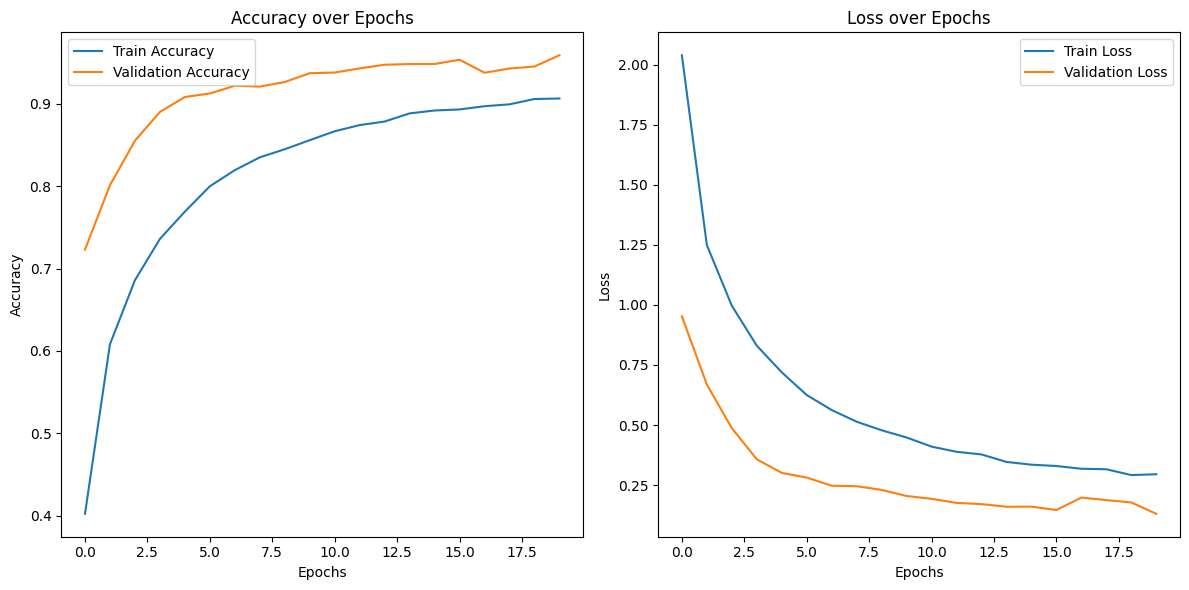

In [ ]:
import matplotlib.pyplot as plt


# Plotting Training & Validation Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Training & Validation Loss
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


In [ ]:
test_dir ='/kaggle/input/new-plant-diseases-dataset/test/test'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


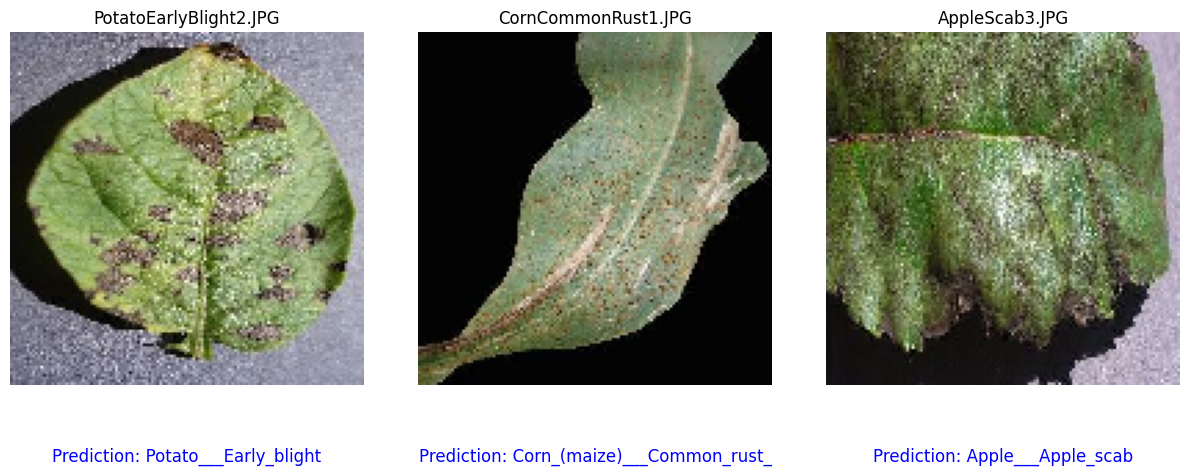

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Define the test directory
test_dir = '/kaggle/input/new-plant-diseases-dataset/test/test'

# List all images in the test directory
all_images = [f for f in os.listdir(test_dir) if f.endswith('.JPG')]

# Randomly select 3 images from the test directory
random_images = random.sample(all_images, 3)

# Preprocess the images and predict using the trained model
plt.figure(figsize=(12, 6))

for i, img_name in enumerate(random_images):
    # Load and preprocess the image
    img_path = os.path.join(test_dir, img_name)
    img = image.load_img(img_path, target_size=(128, 128))  # Resize to match the input size of the model
    img_array = image.img_to_array(img)  # Convert the image to a numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values
    
    # Predict the class using the trained model
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    
    # Get the class label from the class index
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]
    
    # Plot the image
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(img_name, fontsize=12)  # Display image name above the image
    plt.axis('off')  # Hide axes
    
    # Add prediction text below the image
    plt.text(0.5, -0.2, f'Prediction: {predicted_label}', ha='center', va='center', 
             transform=plt.gca().transAxes, fontsize=12, color='blue')

plt.tight_layout()
plt.show()
